In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df_all = pd.read_csv('PreliminaryAnalysis.csv')
min_date = pd.to_datetime('2026-02-22 17:00:00')

In [7]:
df_all['time'] = pd.to_datetime(df_all['time'])
df = df_all.loc[df_all['time'] > min_date]
plt.rcParams['text.usetex'] = True

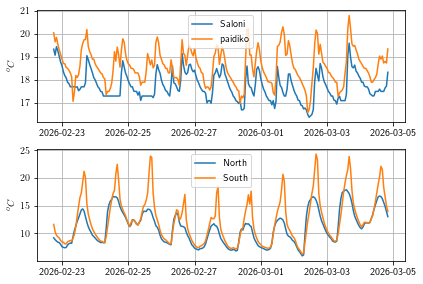

In [22]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), tight_layout=True)

ax[0].plot(df['time'], df['temp_salon_c'], label="Saloni")
ax[0].plot(df['time'], df['temp_kids_c'], label="paidiko")
ax[0].set_ylabel("$^{o}C$")
ax[0].grid()
ax[0].legend()

ax[1].plot(df['time'], df['temp_out_1_b_c'], label="North")
ax[1].plot(df['time'], df['temp_out_2_n_c'], label="South")
ax[1].set_ylabel("$^{o}C$")
ax[1].grid()
ax[1].legend()

plt.show()

## Cooling Rate (<sup>o</sup>C/hour)

### Τι μετράμε

Θέλουμε για κάθε ζώνη (π.χ. Βόρειο μέσα / Νότιο μέσα) να βρούμε τον ρυθμό πτώσης στη “καθαρή” νυχτερινή περίοδο:
π.χ. 00:00–05:00 ή 01:00–06:00
αποφεύγεις ώρες με HVAC/μαγείρεμα/έντονη χρήση

### Απλή μέθοδος (robust)

Για κάθε μέρα:

φιλτράρεις τις ώρες της νύχτας

κάνεις γραμμική παλινδρόμηση T_in = a + b * t

το b είναι το cooling rate (°C/ώρα) — συνήθως αρνητικό

Το ωραίο: βγάζεις ένα rate ανά μέρα → βλέπεις σταθερότητα/μεταβλητότητα.

### cooling rate “κανονικοποιημένο” ως προς έξω

Επειδή άλλοτε έχει 5°C έξω και άλλοτε 12°C, ο σκέτος ρυθμός πτώσης δεν είναι πλήρως συγκρίσιμος.

Ο πιο engineering δείκτης είναι να κοιτάξεις:

ΔT = T_in − T_out (για το αντίστοιχο έξω Β/Ν)
και να κάνεις regression στο ln(ΔT) (δες παρακάτω στο model).

## Thermal model πρώτης τάξης (1st order / RC)

$\frac{dT_{in}}{dt}=−k(T_{in}−T_{out})+u(t)$

Όπου:

k = 1/τ (1/ώρα) είναι το “leakiness” του χώρου (thermal loss rate)

τ = time constant (ώρες): όσο μεγαλύτερο τ, τόσο πιο αργά αλλάζει θερμοκρασία (πιο “αδρανές”/καλύτερα μονωμένο)

u(t) = εσωτερικές πηγές (θέρμανση, άνθρωποι, ήλιος, συσκευές) — ιδανικά τη νύχτα το θεωρούμε ~0

Νυχτερινό fit (ιδανικό για αρχή)

Σε νυχτερινά παράθυρα χωρίς θέρμανση:

$Tin(t)−Tout(t)≈(Tin(0)−Tout(0))e^{−kt}$

Άρα:

$ln⁡(ΔT(t))=ln⁡(ΔT(0))−kt$

Οπότε:

Φτιάχνεις ΔT = T_in − T_out

Κρατάς μόνο σημεία που ΔT > 0 (ώστε να παίρνεις log)

Κάνεις linear regression: ln(ΔT) = c + (-k)*t

Παίρνεις k και μετά τ = 1/k

Γιατί αυτό είναι καλύτερο από “σκέτο cooling rate”

Γιατί το cooling rate σε °C/h εξαρτάται από το “πόσο ζεστό είσαι” σε σχέση με έξω. Το k και το τ είναι πιο “ιδιότητα” του χώρου.